In [ ]:
#Installing required libararies
!pip install pyspark --quiet
!pip install pandas numpy matplotlib seaborn scikit-learn plotly --quiet
!pip install openpyxl python-docx --quiet

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.rdd import RDD
import pyspark.sql.functions as F

In [ ]:
from google.colab import files

print("Please upload your Excel/Word file with telecom data...")
uploaded = files.upload()

Please upload your Excel/Word file with telecom data...


Saving Telecom Churn Rate Dataset.xlsx to Telecom Churn Rate Dataset (2).xlsx


In [ ]:
filename = list(uploaded.keys())[0]
print(f"File uploaded: {filename}")

File uploaded: Telecom Churn Rate Dataset (2).xlsx


In [ ]:
# DATA LOADING AND EXPLORING DATA
#loading the data
if filename.endswith('.xlsx'):
    df = pd.read_excel(filename)
elif filename.endswith('.xls'):
    df = pd.read_excel(filename)
else:
    df = pd.read_csv(filename)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print("\nFirst few rows:")
print(df.head())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())



Dataset Shape: (7043, 23)
Total Records: 7043
Total Features: 23

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingTV  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...          No   
4                No     Fiber optic             No  ...          No   

  Streami

In [ ]:
#data quality
#missing values
print("\nMissing Values Analysis:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing_Count'] > 0])


Missing Values Analysis:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []


In [ ]:
# Duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")



Duplicate Rows: 0


In [ ]:
# Data types analysis
print("\nData Type Distribution:")
print(df.dtypes.value_counts())


Data Type Distribution:
object     18
int64       4
float64     1
Name: count, dtype: int64


In [ ]:
# Basic statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric Columns: {numeric_cols}")


Numeric Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'numAdminTickets', 'numTechTickets']


In [ ]:
#DATA CLEANING

df_clean = df.copy()

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f" Duplicates removed. New shape: {df_clean.shape}")



 Duplicates removed. New shape: (7043, 23)


In [ ]:
# Handling missing values
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f" Filled {col} with median value")
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f" Filled {col} with mode value")

In [ ]:
# Remove rows with remaining null values
df_clean = df_clean.dropna()
print(f" Final cleaned dataset shape: {df_clean.shape}")

 Final cleaned dataset shape: (7043, 23)


In [ ]:
#FEATURE ENGINEERING

df_features = df_clean.copy()

# Identifying churn column (common names)
churn_cols = [col for col in df_features.columns if 'churn' in col.lower()]
if churn_cols:
    churn_col = churn_cols[0]
    print(f" Identified Churn Column: {churn_col}")
# Encoding churn if it's categorical
    if df_features[churn_col].dtype == 'object':
        df_features[churn_col] = (df_features[churn_col].str.lower() == 'yes').astype(int)
else:
    print("Warning: No explicit churn column found. Using last boolean column as churn indicator.")





 Identified Churn Column: Churn


In [ ]:
# Encoding categorical variables
categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

# Explicitly convert 'TotalCharges' to numeric, handling errors
if 'TotalCharges' in categorical_cols:
    df_features['TotalCharges'] = pd.to_numeric(df_features['TotalCharges'], errors='coerce')
    # Fill any NaN values created by coercion (e.g., from empty strings) with the median
    df_features['TotalCharges'].fillna(df_features['TotalCharges'].median(), inplace=True)
    print(" 'TotalCharges' column converted to numeric and NaN values handled.")
    # Re-generate categorical_cols to exclude 'TotalCharges'
    categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()

print(f"\nEncoding {len(categorical_cols)} categorical features...")
for col in categorical_cols:
    if col != churn_col:  # Don't re-encode churn if already done
        le = LabelEncoder()
        df_features[col + '_encoded'] = le.fit_transform(df_features[col])
        label_encoders[col] = le
        print(f" Encoded: {col}")

 'TotalCharges' column converted to numeric and NaN values handled.

Encoding 16 categorical features...
 Encoded: customerID
 Encoded: gender
 Encoded: Partner
 Encoded: Dependents
 Encoded: PhoneService
 Encoded: MultipleLines
 Encoded: InternetService
 Encoded: OnlineSecurity
 Encoded: OnlineBackup
 Encoded: DeviceProtection
 Encoded: TechSupport
 Encoded: StreamingTV
 Encoded: StreamingMovies
 Encoded: Contract
 Encoded: PaperlessBilling
 Encoded: PaymentMethod


In [ ]:
# Creating numeric features from continuous variables
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nIdentified {len(numeric_cols)} numeric features")

print("\n Feature engineering completed!")


Identified 23 numeric features

 Feature engineering completed!



Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn Rate: 26.54%


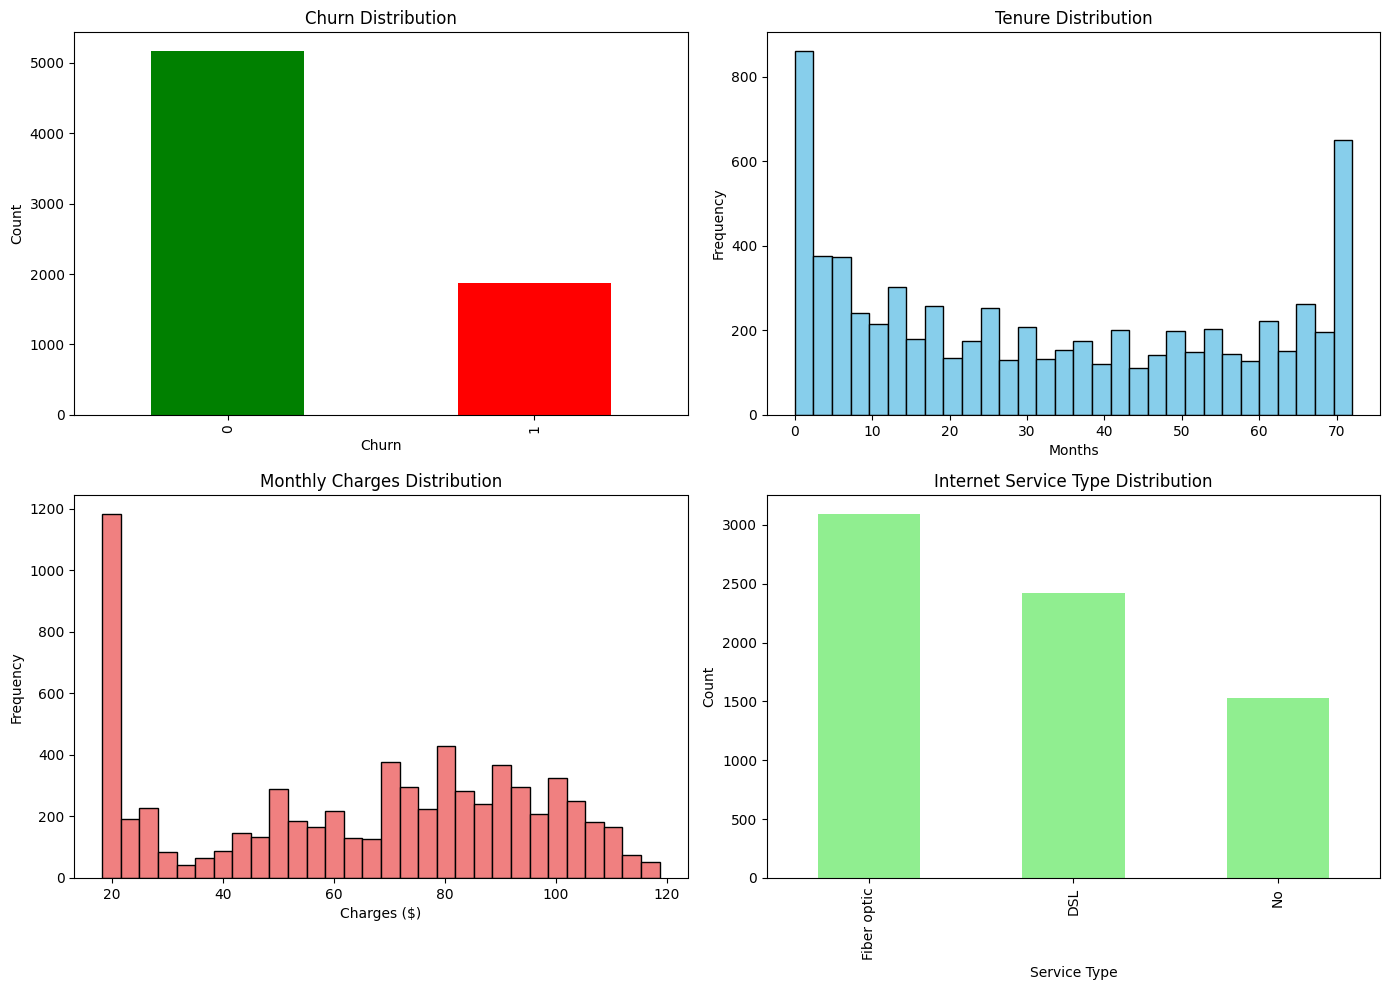

EDA visualizations


In [ ]:
#EXPLORATORY DATA ANALYSIS (EDA)

# Churn distribution
churn_dist = df_features[churn_col].value_counts()
print(f"\nChurn Distribution:")
print(churn_dist)
print(f"Churn Rate: {(df_features[churn_col].sum() / len(df_features)) * 100:.2f}%")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Churn distribution
df_features[churn_col].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Churn Distribution')
axes[0, 0].set_xlabel('Churn')
axes[0, 0].set_ylabel('Count')

# Tenure distribution
if 'tenure' in [col.lower() for col in numeric_cols]:
    tenure_col = [col for col in numeric_cols if 'tenure' in col.lower()][0]
    axes[0, 1].hist(df_features[tenure_col], bins=30, color='skyblue', edgecolor='black')
    axes[0, 1].set_title('Tenure Distribution')
    axes[0, 1].set_xlabel('Months')
    axes[0, 1].set_ylabel('Frequency')
# Monthly charges
if 'monthlycharges' in [col.lower() for col in numeric_cols]:
    monthly_col = [col for col in numeric_cols if 'monthlycharges' in col.lower()][0]
    axes[1, 0].hist(df_features[monthly_col], bins=30, color='lightcoral', edgecolor='black')
    axes[1, 0].set_title('Monthly Charges Distribution')
    axes[1, 0].set_xlabel('Charges ($)')
    axes[1, 0].set_ylabel('Frequency')

# Internet service usage
if 'internetservice' in [col.lower() for col in categorical_cols]:
    internet_col = [col for col in categorical_cols if 'internetservice' in col.lower()][0]
    df_features[internet_col].value_counts().plot(kind='bar', ax=axes[1, 1], color='lightgreen')
    axes[1, 1].set_title('Internet Service Type Distribution')
    axes[1, 1].set_xlabel('Service Type')
    axes[1, 1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print("EDA visualizations")

In [ ]:
#INITIALLIZING SPARK SESSION

spark = SparkSession.builder \
    .appName("TelecomChurnAnalysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", 200) \
    .getOrCreate()
print("Spark Session initialized!")
print(f"Spark Version: {spark.version}")

Spark Session initialized!
Spark Version: 3.5.1


In [ ]:
# Converting pandas dataframe to Spark DataFrame
spark_df = spark.createDataFrame(df_features)
print(f"Converted to Spark DataFrame with {spark_df.count()} rows")

Converted to Spark DataFrame with 7043 rows



SPARK OPERATIONS: RDD vs DATAFRAME vs SQL COMPARISON

1. RDD OPERATIONS (Resilient Distributed Dataset)
------------------------------------------------------------
RDD Execution Time: 1.5883 seconds
RDD Results (Churn vs Feature Stats):
  Churn 0: Mean=0.13, StdDev=0.33
  Churn 1: Mean=0.25, StdDev=0.44

2. DATAFRAME OPERATIONS
------------------------------------------------------------
DataFrame Execution Time: 0.6646 seconds
DataFrame Results:
  Row(Churn=0, avg_value=0.12872052570545034, std_value=0.3349227256306397, count=5174)
  Row(Churn=1, avg_value=0.2546816479400749, std_value=0.4357987175972197, count=1869)

3. SPARK SQL OPERATIONS
------------------------------------------------------------
SQL Execution Time: 0.5144 seconds
SQL Results:
  Row(Churn=0, avg_value=0.12872052570545034, std_value=0.3349227256306397, count=5174)
  Row(Churn=1, avg_value=0.2546816479400749, std_value=0.4357987175972197, count=1869)

EXECUTION TIME COMPARISON
   Method  Execution Time (s)
      

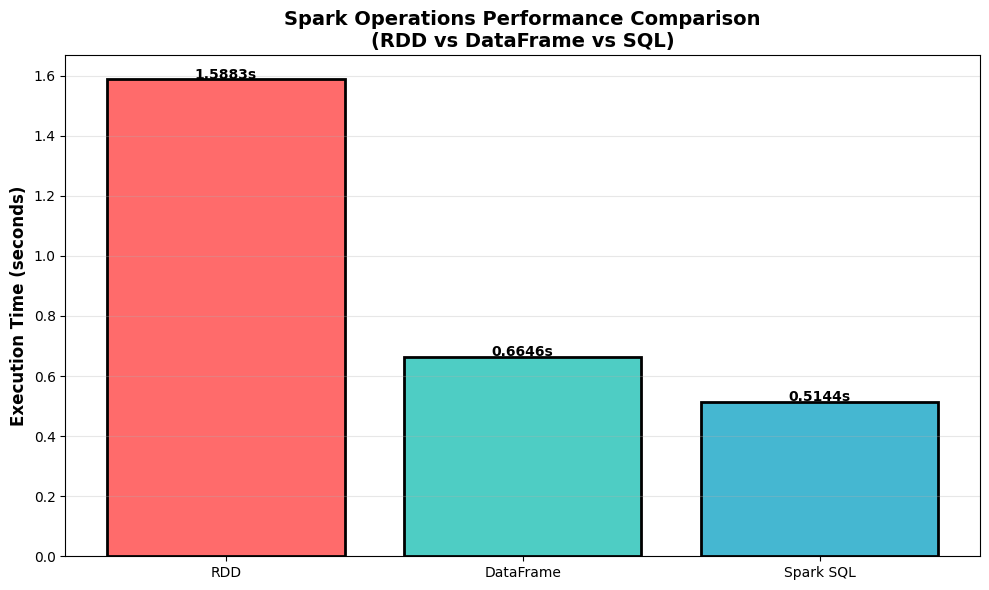

 Spark comparison visualizations saved


In [ ]:
#SPARK OPERATIONS - RDD VS DATAFRAME VS SQL
print("\n" + "=" * 80)
print("SPARK OPERATIONS: RDD vs DATAFRAME vs SQL COMPARISON")
print("=" * 80)

# Select a numeric column for analysis
analysis_col = numeric_cols[0] if numeric_cols else None

results_comparison = {}

# -------- METHOD 1: RDD OPERATIONS --------
print("\n1. RDD OPERATIONS (Resilient Distributed Dataset)")
print("-" * 60)

start_time = time.time()
rdd_data = spark_df.rdd.map(lambda row: (row[churn_col], row[analysis_col])) \
    .filter(lambda x: x[1] is not None) \
    .cache()

rdd_result = rdd_data.groupByKey() \
    .mapValues(lambda x: (np.mean(list(x)), np.std(list(x)))) \
    .collect()

rdd_time = time.time() - start_time

print(f"RDD Execution Time: {rdd_time:.4f} seconds")
print("RDD Results (Churn vs Feature Stats):")
for churn_val, (mean, std) in rdd_result:
    print(f"  Churn {churn_val}: Mean={mean:.2f}, StdDev={std:.2f}")

results_comparison['RDD'] = {'time': rdd_time, 'method': 'RDD'}

# -------- METHOD 2: DATAFRAME OPERATIONS --------
print("\n2. DATAFRAME OPERATIONS")
print("-" * 60)

start_time = time.time()
df_result = spark_df.groupBy(churn_col) \
    .agg(F.mean(analysis_col).alias('avg_value'),
         F.stddev(analysis_col).alias('std_value'),
         F.count('*').alias('count')) \
    .collect()

df_time = time.time() - start_time

print(f"DataFrame Execution Time: {df_time:.4f} seconds")
print("DataFrame Results:")
for row in df_result:
    print(f"  {row}")

results_comparison['DataFrame'] = {'time': df_time, 'method': 'DataFrame'}

# -------- METHOD 3: SPARK SQL OPERATIONS --------
print("\n3. SPARK SQL OPERATIONS")
print("-" * 60)

spark_df.createOrReplaceTempView("telecom_data")

start_time = time.time()
sql_result = spark.sql(f"""
    SELECT {churn_col},
           AVG({analysis_col}) as avg_value,
           STDDEV({analysis_col}) as std_value,
           COUNT(*) as count
    FROM telecom_data
    GROUP BY {churn_col}
""").collect()

sql_time = time.time() - start_time

print(f"SQL Execution Time: {sql_time:.4f} seconds")
print("SQL Results:")
for row in sql_result:
    print(f"  {row}")

results_comparison['SQL'] = {'time': sql_time, 'method': 'SQL'}

# -------- COMPARISON SUMMARY --------
print("\n" + "=" * 60)
print("EXECUTION TIME COMPARISON")
print("=" * 60)
comparison_df = pd.DataFrame([
    {'Method': 'RDD', 'Execution Time (s)': rdd_time},
    {'Method': 'DataFrame', 'Execution Time (s)': df_time},
    {'Method': 'Spark SQL', 'Execution Time (s)': sql_time}
])
print(comparison_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
methods = comparison_df['Method'].tolist()
times = comparison_df['Execution Time (s)'].tolist()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax.bar(methods, times, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Spark Operations Performance Comparison\n(RDD vs DataFrame vs SQL)',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(times):
    ax.text(i, v + 0.001, f'{v:.4f}s', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('spark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Spark comparison visualizations saved")





In [ ]:
#CHURN PREDICTION ANALYSIS

# Preparing data for ML
X = df_features.drop(columns=[churn_col] + categorical_cols)
y = df_features[churn_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Random Forest classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nChurn Prediction Model Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Most Important Features:")
print(feature_importance.to_string(index=False))






Training Random Forest Classifier...

Churn Prediction Model Performance:
  Accuracy:  0.8609
  Precision: 0.7565
  Recall:    0.6997
  F1-Score:  0.7270
  ROC-AUC:   0.9302

Top 10 Most Important Features:
                Feature  Importance
         numTechTickets    0.217317
                 tenure    0.135110
           TotalCharges    0.106029
       Contract_encoded    0.095961
         MonthlyCharges    0.094278
     customerID_encoded    0.051763
 OnlineSecurity_encoded    0.049514
    TechSupport_encoded    0.044594
InternetService_encoded    0.028653
   OnlineBackup_encoded    0.027681


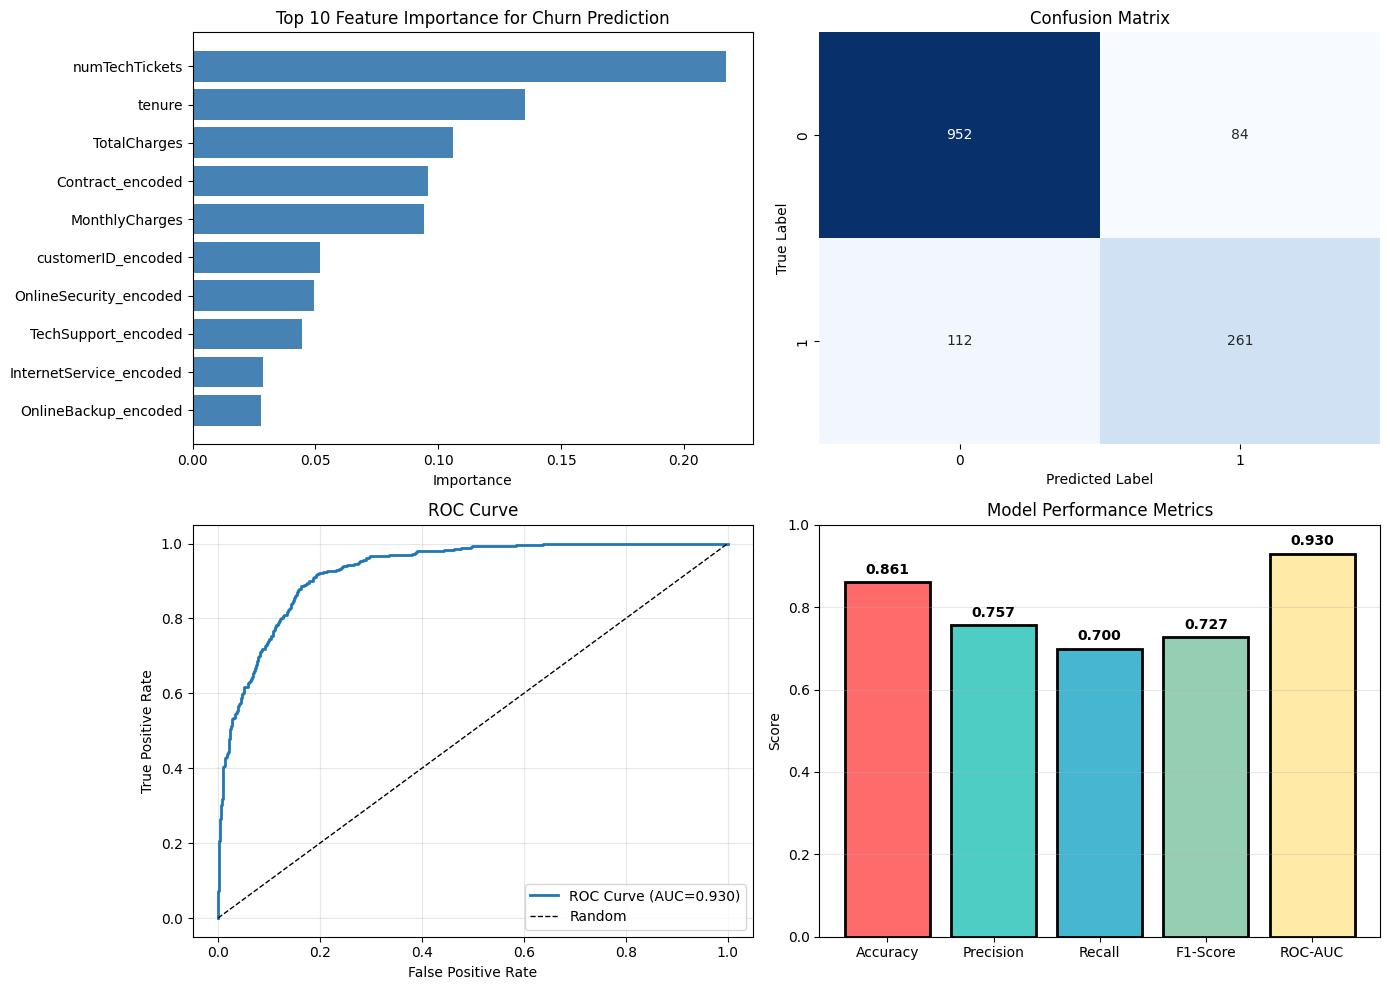

Churn prediction visualizations


In [ ]:

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Feature importance
axes[0, 0].barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Top 10 Feature Importance for Churn Prediction')
axes[0, 0].invert_yaxis()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1, 0].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC={roc_auc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Model metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [accuracy, precision, recall, f1, roc_auc]
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
axes[1, 1].bar(metrics, values, color=colors_bar, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Model Performance Metrics')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_prediction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Churn prediction visualizations")

In [ ]:
 #ANAMOLY DETECTION

from sklearn.ensemble import IsolationForest

# Preparing data for anomaly detection
X_anomaly = df_features.drop(columns=[churn_col] + categorical_cols)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomaly)

# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_scaled)
anomaly_scores = iso_forest.score_samples(X_scaled)

df_features['Anomaly'] = anomaly_labels
df_features['Anomaly_Score'] = anomaly_scores

n_anomalies = (anomaly_labels == -1).sum()
print(f"Number of Anomalies Detected: {n_anomalies} ({(n_anomalies/len(df_features))*100:.2f}%)")

# Analyze anomalies
print("\nAnomalies Statistics:")
anomaly_analysis = pd.DataFrame({
    'Normal': [len(df_features[df_features['Anomaly'] == 1])],
    'Anomaly': [len(df_features[df_features['Anomaly'] == -1])]
})
print(anomaly_analysis)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Anomaly distribution
anomaly_counts = pd.Series(anomaly_labels).map({1: 'Normal', -1: 'Anomaly'}).value_counts()
axes[0, 0].bar(anomaly_counts.index, anomaly_counts.values, color=['green', 'red'], edgecolor='black')
axes[0, 0].set_title('Anomaly Distribution')
axes[0, 0].set_ylabel('Count')

# Anomaly scores distribution
axes[0, 1].hist(anomaly_scores, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(np.percentile(anomaly_scores, 5), color='red', linestyle='--',
                    linewidth=2, label='Anomaly Threshold')
axes[0, 1].set_title('Anomaly Score Distribution')
axes[0, 1].set_xlabel('Anomaly Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()


# Anomaly vs Churn
anomaly_churn = pd.crosstab(df_features['Anomaly'], df_features[churn_col])
anomaly_churn.plot(kind='bar', ax=axes[1, 0], color=['green', 'red'])
axes[1, 0].set_title('Anomaly vs Churn Status')
axes[1, 0].set_xlabel('Anomaly')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(['No Churn', 'Churn'])

# Anomaly score box plot
df_features.boxplot(column='Anomaly_Score', by='Anomaly', ax=axes[1, 1])
axes[1, 1].set_title('Anomaly Score by Anomaly Status')
axes[1, 1].set_xlabel('Anomaly Status')
axes[1, 1].set_ylabel('Anomaly Score')

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()
print("Anomaly detection visualizations")



NETWORK CONGESTION & RESOURCE UTILIZATION ANALYSIS
Analyzing network utilization using: InternetService_encoded

Congestion Level Counts:
Congestion_Risk
Low          1761
Medium       1761
Very High    1761
High         1760
Name: count, dtype: int64

Churn Rate by Congestion Level:
Churn                0      1
Congestion_Risk              
Low              81.37  18.63
Medium           66.33  33.67
High             58.52  41.48
Very High        87.62  12.38


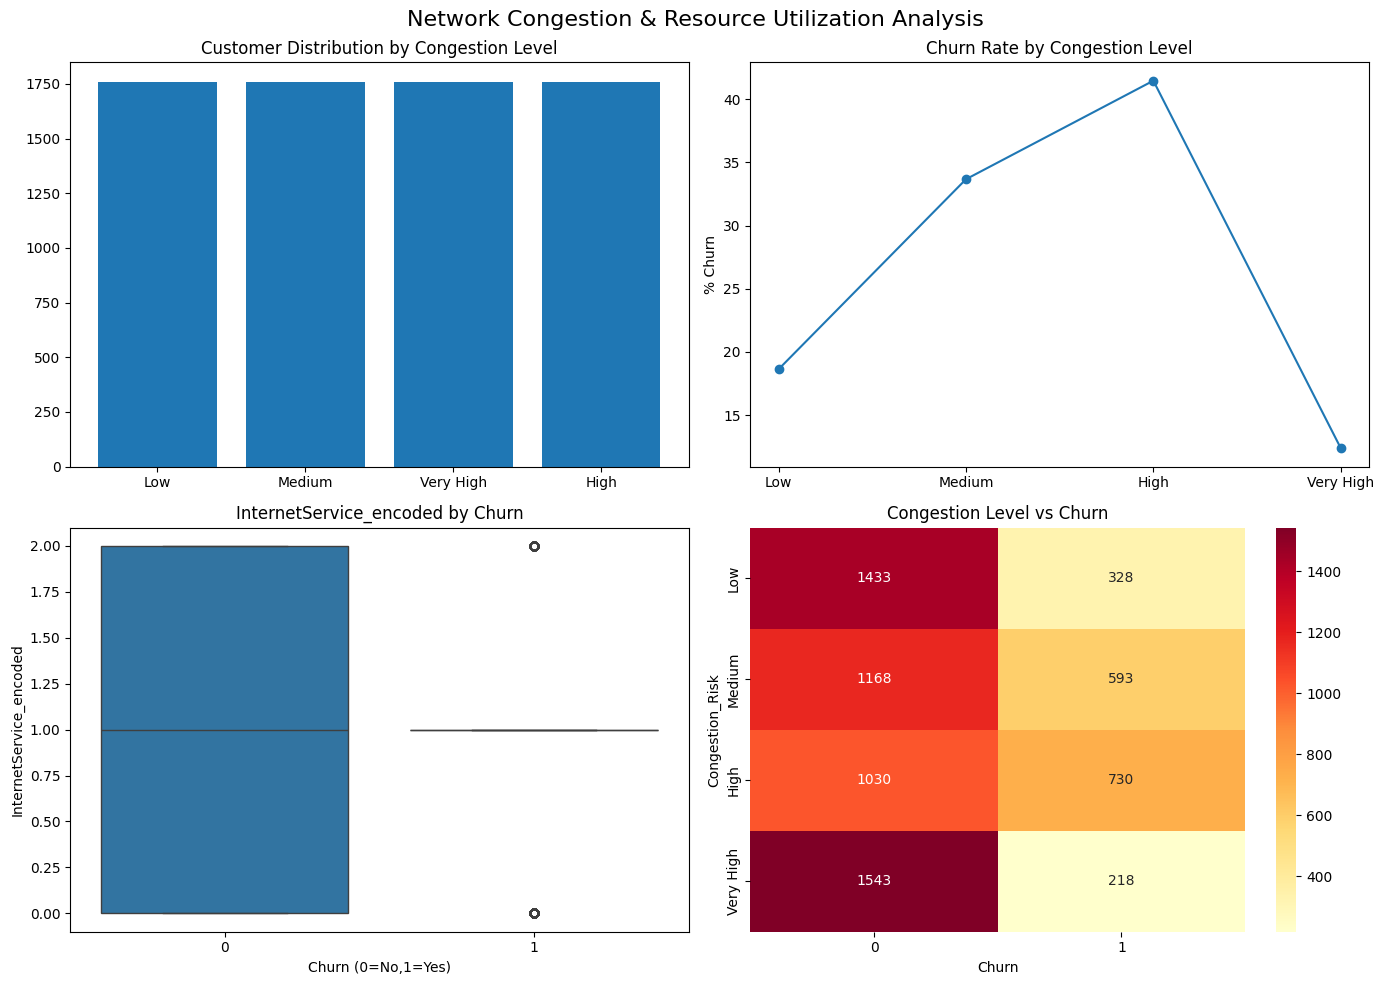

In [ ]:
#NETWORK CONGESTION ANALYSIS
# Force conversion to Pandas
# Because our Google Collab loaded PySpark, our->InternetService_encoded column is a PySpark Column, not a Pandas columnso any math on it triggers PySpark errors even though it looks numeric
# so we must convert the entire df_features to a pure Pandas dataframe before analysis to avoid spark issues.




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 80)
print("NETWORK CONGESTION & RESOURCE UTILIZATION ANALYSIS")
print("=" * 80)

# Ensure df_features is a Pandas DataFrame
df_features = df_features.toPandas() if not isinstance(df_features, pd.DataFrame) else df_features

# Detect numeric columns
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()

# Identify data usage metric
data_terms = ['data','usage','internet','fiber','bandwidth','mb','gb','throughput']
data_cols = [col for col in numeric_cols if any(t in col.lower() for t in data_terms)]

# Fallback for encoded InternetService columns
if not data_cols:
    for c in df_features.columns:
        if "internetservice" in c.lower():
            data_cols = [c]
            break

if not data_cols:
    print("⚠ No data-usage or InternetService column found.")
else:
    primary_data_col = data_cols[0]
    print(f"Analyzing network utilization using: {primary_data_col}")

    # Clean column to ensure it's numeric
    df_features[primary_data_col] = pd.to_numeric(df_features[primary_data_col], errors='coerce')

    # Quartile-based risk segmentation
    df_features['Congestion_Risk'] = pd.qcut(
        df_features[primary_data_col].rank(method='first'),
        q=4,
        labels=['Low','Medium','High','Very High']
    )

    print("\nCongestion Level Counts:")
    print(df_features['Congestion_Risk'].value_counts())

    # Detect churn column
    churn_col = next((c for c in df_features.columns if 'churn' in c.lower()), None)

    if churn_col:
        df_features[churn_col] = pd.to_numeric(df_features[churn_col], errors='coerce').fillna(0).astype(int)

        churn_rate = pd.crosstab(
            df_features['Congestion_Risk'],
            df_features[churn_col],
            normalize='index'
        ) * 100

        print("\nChurn Rate by Congestion Level:")
        print(churn_rate.round(2))
    else:
        print("\n⚠ No churn column found. Skipping churn analysis.")

    # --- Visualization ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Network Congestion & Resource Utilization Analysis', fontsize=16)

    # 1. Distribution of congestion
    axes[0,0].bar(
        df_features['Congestion_Risk'].value_counts().index,
        df_features['Congestion_Risk'].value_counts().values
    )
    axes[0,0].set_title("Customer Distribution by Congestion Level")

    # 2. Churn vs Congestion
    if churn_col:
        churn_by_cong = df_features.groupby('Congestion_Risk')[churn_col].mean() * 100
        axes[0,1].plot(churn_by_cong.index, churn_by_cong.values, marker='o')
        axes[0,1].set_title("Churn Rate by Congestion Level")
        axes[0,1].set_ylabel("% Churn")

    # 3. Boxplot of usage by churn
    if churn_col:
        sns.boxplot(x=df_features[churn_col], y=df_features[primary_data_col], ax=axes[1,0])
        axes[1,0].set_title(f"{primary_data_col} by Churn")
        axes[1,0].set_xlabel("Churn (0=No,1=Yes)")

    # 4. Heatmap
    if churn_col:
        heat = pd.crosstab(df_features['Congestion_Risk'], df_features[churn_col])
        sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,1])
        axes[1,1].set_title("Congestion Level vs Churn")

    plt.tight_layout()
    plt.show()


Analyzing profitability: PhoneService vs MonthlyCharges

Profitability by PhoneService:
              Total_Revenue  Avg_Monthly_Charge  Customer_Count  Churn_Rate
PhoneService                                                               
Yes                427453.1               67.20            6361        0.27
No                  28663.5               42.03             682        0.25


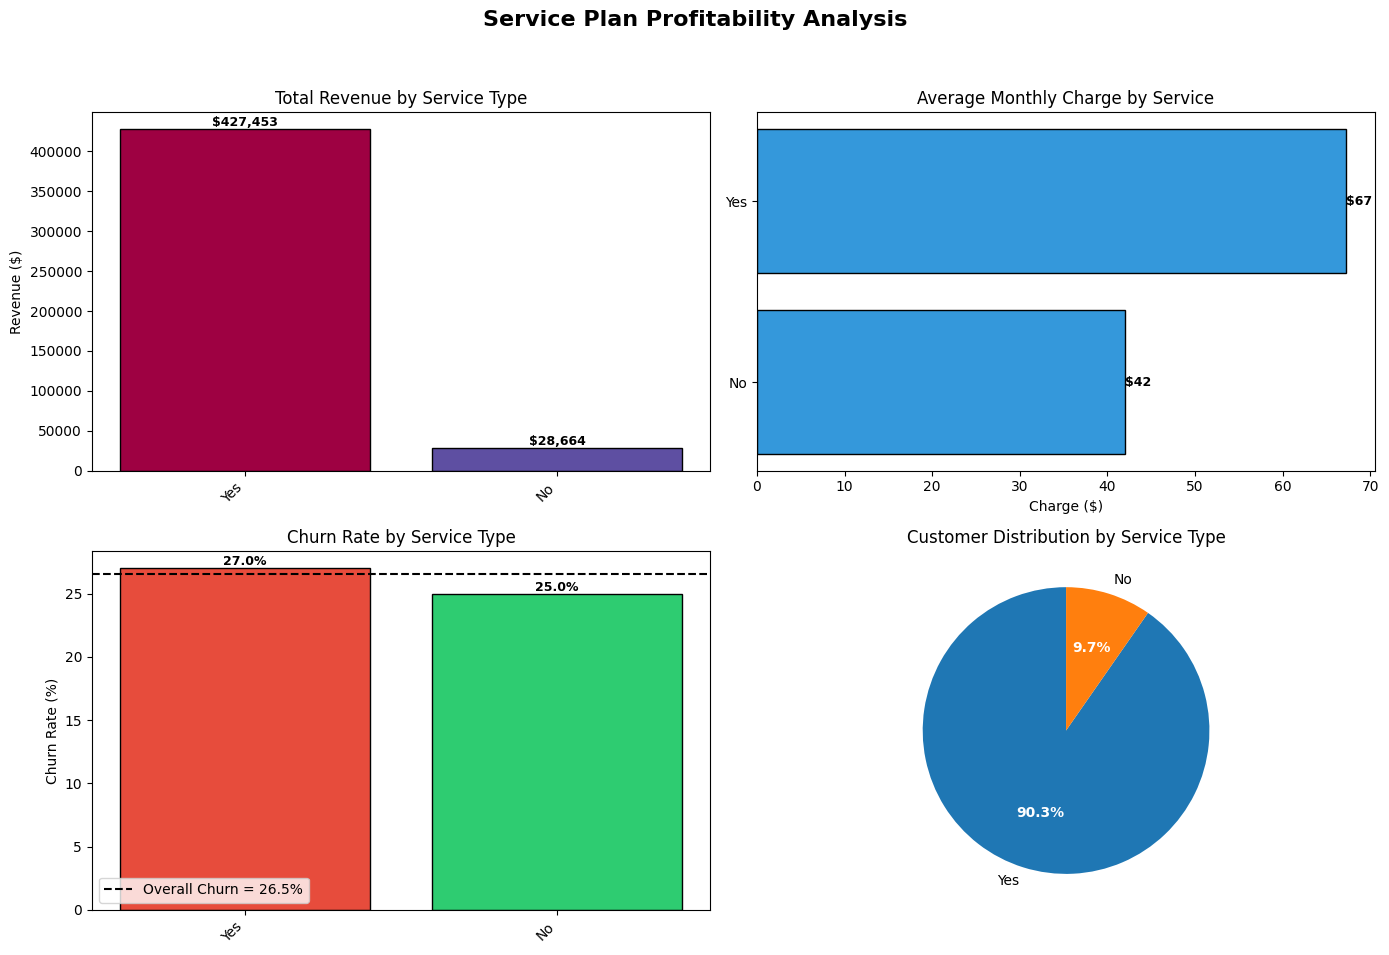

Service profitability visualization saved to: service_profitability.png


In [ ]:
# SERVICE PLAN PROFITABILITY ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Ensure df_features exists (assumes you have a dataframe named df_features) ---
# If you only have df, uncomment the next line:
# df_features = df.copy()

# Detect column type lists if not already present
if 'categorical_cols' not in globals():
    categorical_cols = df_features.select_dtypes(include=['object', 'category']).columns.tolist()
if 'numeric_cols' not in globals():
    numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()

# Detect churn column if not present
if 'churn_col' not in globals():
    churn_candidates = [c for c in df_features.columns if 'churn' in c.lower() or 'exited' in c.lower() or 'target' in c.lower()]
    churn_col = churn_candidates[0] if churn_candidates else None

# Identify service & charge columns with fallbacks
service_cols = [col for col in categorical_cols if any(term in col.lower() for term in ['service', 'plan', 'internet', 'phone'])]
charge_cols = [col for col in numeric_cols if 'charge' in col.lower()]

# fallback: common names
if not charge_cols:
    for cand in ['TotalCharges', 'monthlycharge', 'monthly_charge', 'monthlycharges', 'monthly_charges', 'monthly_bill']:
        if cand in df_features.columns:
            charge_cols = [cand]
            break

if service_cols and charge_cols:
    service_col = service_cols[0]
    charge_col = charge_cols[0]

    print(f"Analyzing profitability: {service_col} vs {charge_col}")

    # Ensure charge column numeric
    df_features[charge_col] = pd.to_numeric(df_features[charge_col], errors='coerce').fillna(0)

    # Make sure churn column numeric 0/1 if exists
    if churn_col:
        ser = df_features[churn_col]
        if ser.dtype == object:
            mapped = ser.astype(str).str.strip().str.lower().map({'yes':1,'y':1,'true':1,'1':1,'no':0,'n':0,'false':0,'0':0})
            if mapped.notna().any():
                df_features['_churn_numeric_'] = mapped.fillna(0).astype(int)
                churn_use = '_churn_numeric_'
            else:
                df_features['_churn_numeric_'] = pd.to_numeric(ser, errors='coerce').fillna(0).astype(int)
                churn_use = '_churn_numeric_'
        else:
            df_features['_churn_numeric_'] = pd.to_numeric(ser, errors='coerce').fillna(0).astype(int)
            churn_use = '_churn_numeric_'
        overall_churn_rate = df_features[churn_use].mean()  # fraction 0..1
    else:
        churn_use = None
        overall_churn_rate = 0.0

    # Aggregate profitability
    profitability = df_features.groupby(service_col).agg(
        Total_Revenue=(charge_col, 'sum'),
        Avg_Monthly_Charge=(charge_col, 'mean'),
        Customer_Count=(charge_col, 'count'),
        Churn_Rate=(churn_use if churn_use else charge_col, 'mean')  # if no churn, this will be mean(charge_col) but we'll fix below
    ).round(2)

    # If churn not available, set Churn_Rate to NaN
    if not churn_use:
        profitability['Churn_Rate'] = np.nan
    else:
        # Churn_Rate is already a fraction (0..1); keep it that way
        pass

    profitability = profitability.sort_values('Total_Revenue', ascending=False)

    print(f"\nProfitability by {service_col}:")
    print(profitability)

    # Compute CLV (simple): Avg_Monthly_Charge * avg_tenure * (1 - churn_rate)
    if 'tenure' in df_features.columns:
        avg_tenure = df_features['tenure'].replace(0, np.nan).mean()
        if np.isnan(avg_tenure):
            avg_tenure = 12
    else:
        # fallback to a reasonable default (12 months)
        avg_tenure = 12

    # If Churn_Rate is NaN (no churn data), CLV will be NaN — that's expected
    profitability['CLV'] = profitability['Avg_Monthly_Charge'] * avg_tenure * (1 - profitability['Churn_Rate'])

    # --- Visualizations ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Service Plan Profitability Analysis', fontsize=16, fontweight='bold')

    # 1. Revenue by service (bar)
    ax1 = axes[0, 0]
    revenue_data = profitability['Total_Revenue'].sort_values(ascending=False)
    colors_rev = plt.cm.Spectral(np.linspace(0, 1, len(revenue_data)))
    ax1.bar(range(len(revenue_data)), revenue_data.values, color=colors_rev, edgecolor='black', linewidth=1)
    ax1.set_xticks(range(len(revenue_data)))
    ax1.set_xticklabels(revenue_data.index, rotation=45, ha='right')
    ax1.set_title('Total Revenue by Service Type')
    ax1.set_ylabel('Revenue ($)')
    for i, v in enumerate(revenue_data.values):
        ax1.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    # 2. Average charge by service (horizontal bar)
    ax2 = axes[0, 1]
    avg_charge = profitability['Avg_Monthly_Charge'].sort_values(ascending=True)  # ascending for horizontal bar
    ax2.barh(range(len(avg_charge)), avg_charge.values, color='#3498db', edgecolor='black', linewidth=1)
    ax2.set_yticks(range(len(avg_charge)))
    ax2.set_yticklabels(avg_charge.index)
    ax2.set_title('Average Monthly Charge by Service')
    ax2.set_xlabel('Charge ($)')
    for i, v in enumerate(avg_charge.values):
        ax2.text(v, i, f'${v:,.0f}', ha='left', va='center', fontweight='bold', fontsize=9)

    # 3. Churn rate by service
    ax3 = axes[1, 0]
    if churn_use:
        churn_by_service = (profitability['Churn_Rate'] * 100).sort_values(ascending=False)
        # color based on whether above overall churn_rate (convert overall_churn_rate to percent)
        overall_churn_pct = overall_churn_rate * 100
        colors_churn = ['#2ecc71' if x < overall_churn_pct else '#e74c3c' for x in churn_by_service]
        ax3.bar(range(len(churn_by_service)), churn_by_service.values, color=colors_churn, edgecolor='black', linewidth=1)
        ax3.axhline(overall_churn_pct, color='black', linestyle='--', linewidth=1.5, label=f'Overall Churn = {overall_churn_pct:.1f}%')
        ax3.set_xticks(range(len(churn_by_service)))
        ax3.set_xticklabels(churn_by_service.index, rotation=45, ha='right')
        ax3.set_title('Churn Rate by Service Type')
        ax3.set_ylabel('Churn Rate (%)')
        ax3.legend()
        for i, v in enumerate(churn_by_service.values):
            ax3.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    else:
        ax3.text(0.5, 0.5, 'Churn data not available', ha='center', va='center', fontsize=12)
        ax3.set_title('Churn Rate by Service Type')

    # 4. Customer count by service (pie)
    ax4 = axes[1, 1]
    customer_dist = profitability['Customer_Count'].sort_values(ascending=False)
    if customer_dist.sum() > 0:
        wedges, texts, autotexts = ax4.pie(customer_dist.values, labels=customer_dist.index, autopct='%1.1f%%', startangle=90)
        ax4.set_title('Customer Distribution by Service Type')
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
    else:
        ax4.text(0.5, 0.5, 'No customers found', ha='center', va='center')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    out_path = 'service_profitability.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print("Service profitability visualization saved to:", out_path)
else:
    print("Insufficient columns for profitability analysis (need at least one service col and one charge col).")


CREATING COMPREHENSIVE EXECUTIVE DASHBOARD

KEY METRICS SUMMARY:
  Total Customers.........................            7043
  Churned Customers.......................            1869
  Churn Rate (%)..........................           26.54
  Anomalies Detected......................             353
  Normal Records..........................            6690
  Model Accuracy..........................           86.09
  Model ROC-AUC...........................           93.02
  Average Anomaly Score...................           -0.53


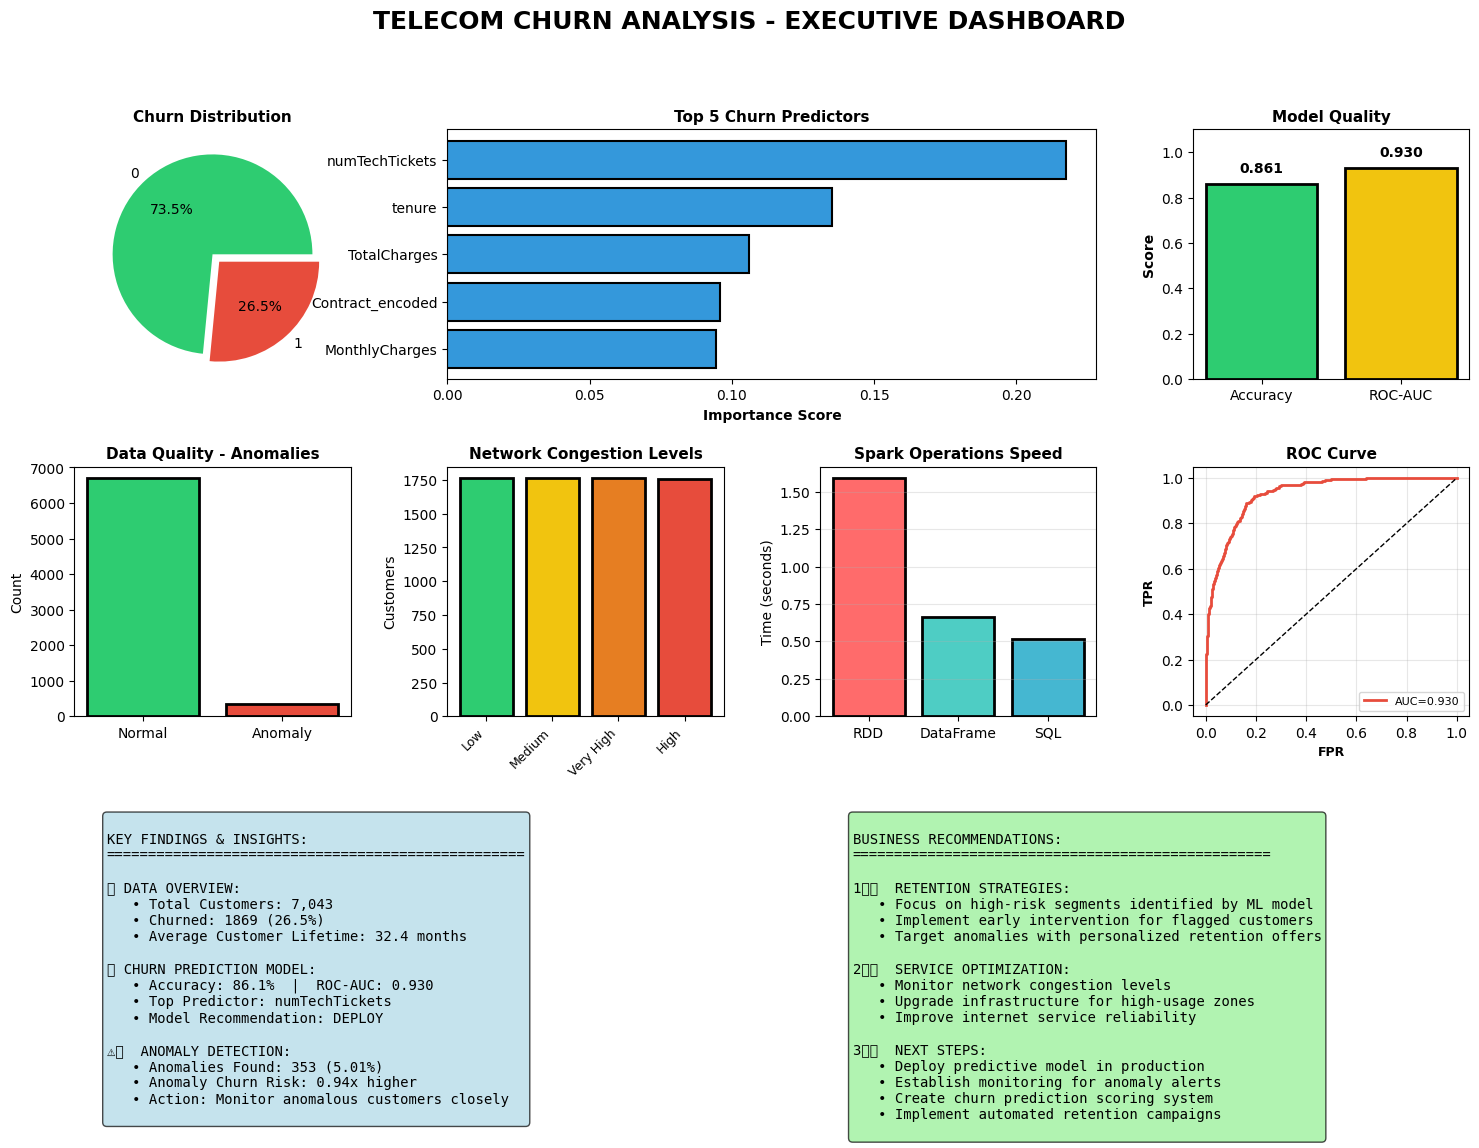

Executive dashboard


In [ ]:
# COMPREHENSIVE EXECUTIVE DASHBOARD


import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score

print("\n" + "=" * 80)
print("CREATING COMPREHENSIVE EXECUTIVE DASHBOARD")
print("=" * 80)

# Ensure anomaly churn rate is defined
# n_anomalies and anomaly_labels were defined in cell oAvly1moXYGF
if 'Anomaly' in df_features.columns and n_anomalies > 0:
    anomaly_churn_rate = df_features[df_features['Anomaly'] == -1][churn_col].mean()
else:
    anomaly_churn_rate = 0

# Define n_normal using existing n_anomalies and df_features length
n_normal = len(df_features) - n_anomalies

# Use the already calculated overall_churn_rate (float) instead of the 'churn_rate' DataFrame
anomaly_risk_factor = anomaly_churn_rate / overall_churn_rate if overall_churn_rate > 0 else 0

# Summary statistics
summary_stats = {
    'Total Customers': len(df_features),
    'Churned Customers': int(df_features[churn_col].sum()),
    'Churn Rate (%)': overall_churn_rate * 100, # Use overall_churn_rate as percentage
    'Anomalies Detected': n_anomalies,
    'Normal Records': n_normal,
    'Model Accuracy': accuracy * 100,
    'Model ROC-AUC': roc_auc * 100,
    'Average Anomaly Score': anomaly_scores.mean()
}

print("\nKEY METRICS SUMMARY:")
print("=" * 60)
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"  {key:.<40} {value:>15.2f}")
    else:
        print(f"  {key:.<40} {value:>15}")

# Create dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.35)
fig.suptitle('TELECOM CHURN ANALYSIS - EXECUTIVE DASHBOARD', fontsize=18, fontweight='bold', y=0.98)

# 1. Churn overview
ax1 = fig.add_subplot(gs[0, 0])
churn_dist.plot(kind='pie', ax=ax1, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
ax1.set_title('Churn Distribution', fontweight='bold', fontsize=11)
ax1.set_ylabel('')

# 2. Top predictive features
ax2 = fig.add_subplot(gs[0, 1:3])
top_5_features = feature_importance.head(5)
ax2.barh(top_5_features['Feature'], top_5_features['Importance'], color='#3498db', edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Importance Score', fontweight='bold')
ax2.set_title('Top 5 Churn Predictors', fontweight='bold', fontsize=11)
ax2.invert_yaxis()

# 3. Model accuracy
ax3 = fig.add_subplot(gs[0, 3])
metrics_mini = ['Accuracy', 'ROC-AUC']
values_mini = [accuracy, roc_auc]
ax3.bar(metrics_mini, values_mini, color=['#2ecc71', '#f1c40f'], edgecolor='black', linewidth=2)
ax3.set_ylabel('Score', fontweight='bold')
ax3.set_title('Model Quality', fontweight='bold', fontsize=11)
ax3.set_ylim([0, 1.1])
for i, v in enumerate(values_mini):
    ax3.text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold')

# 4. Anomaly status
ax4 = fig.add_subplot(gs[1, 0])
anomaly_dist = pd.Series({'Normal': n_normal, 'Anomaly': n_anomalies})
colors_anom = ['#2ecc71', '#e74c3c']
ax4.bar(anomaly_dist.index, anomaly_dist.values, color=colors_anom, edgecolor='black', linewidth=2)
ax4.set_title('Data Quality - Anomalies', fontweight='bold', fontsize=11)
ax4.set_ylabel('Count')

# 5. Congestion analysis
if 'Congestion_Risk' in df_features.columns:
    ax5 = fig.add_subplot(gs[1, 1])
    cong_dist = df_features['Congestion_Risk'].value_counts()
    colors_cong = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
    ax5.bar(range(len(cong_dist)), cong_dist.values, color=colors_cong, edgecolor='black', linewidth=2)
    ax5.set_xticks(range(len(cong_dist)))
    ax5.set_xticklabels(cong_dist.index, rotation=45, ha='right', fontsize=9)
    ax5.set_title('Network Congestion Levels', fontweight='bold', fontsize=11)
    ax5.set_ylabel('Customers')

# 6. Spark performance
ax6 = fig.add_subplot(gs[1, 2])
spark_methods = ['RDD', 'DataFrame', 'SQL']
spark_times = [results_comparison['RDD']['time'], results_comparison['DataFrame']['time'], results_comparison['SQL']['time']] # Extract 'time' values
colors_spark = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax6.bar(spark_methods, spark_times, color=colors_spark, edgecolor='black', linewidth=2)
ax6.set_title('Spark Operations Speed', fontweight='bold', fontsize=11)
ax6.set_ylabel('Time (seconds)')
ax6.grid(axis='y', alpha=0.3)

# 7. ROC Curve (safely)
ax7 = fig.add_subplot(gs[1, 3])
if 'y_test' in globals() and 'y_pred_proba' in globals() and len(y_test) == len(y_pred_proba):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    ax7.plot(fpr, tpr, linewidth=2, label=f'AUC={roc_auc:.3f}', color='#e74c3c')
    ax7.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax7.set_xlabel('FPR', fontsize=9, fontweight='bold')
    ax7.set_ylabel('TPR', fontsize=9, fontweight='bold')
    ax7.set_title('ROC Curve', fontweight='bold', fontsize=11)
    ax7.legend(fontsize=8)
    ax7.grid(alpha=0.3)
else:
    ax7.text(0.5, 0.5, "ROC not available", ha='center', va='center', fontsize=12, fontweight='bold')
    ax7.axis('off')

# 8. Key insights
ax8 = fig.add_subplot(gs[2, :2])
insights = f"""
KEY FINDINGS & INSIGHTS:
{'='*50}

📊 DATA OVERVIEW:
   • Total Customers: {len(df_features):,}
   • Churned: {int(df_features[churn_col].sum())} ({overall_churn_rate*100:.1f}%)
   • Average Customer Lifetime: {df_features['tenure'].mean():.1f} months

🎯 CHURN PREDICTION MODEL:
   • Accuracy: {accuracy:.1%}  |  ROC-AUC: {roc_auc:.3f}
   • Top Predictor: {feature_importance.iloc[0]['Feature']}
   • Model Recommendation: {'DEPLOY' if roc_auc > 0.75 else 'OPTIMIZE'}

⚠️  ANOMALY DETECTION:
   • Anomalies Found: {n_anomalies} ({(n_anomalies/len(df_features))*100:.2f}%)
   • Anomaly Churn Risk: {anomaly_risk_factor:.2f}x higher
   • Action: Monitor anomalous customers closely
"""
ax8.text(0.05, 0.95, insights, fontsize=10, family='monospace',
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax8.axis('off')

# 9. Recommendations
ax9 = fig.add_subplot(gs[2, 2:])
recommendations = f"""
BUSINESS RECOMMENDATIONS:
{'='*50}

1️⃣  RETENTION STRATEGIES:
   • Focus on high-risk segments identified by ML model
   • Implement early intervention for flagged customers
   • Target anomalies with personalized retention offers

2️⃣  SERVICE OPTIMIZATION:
   • Monitor network congestion levels
   • Upgrade infrastructure for high-usage zones
   • Improve internet service reliability

3️⃣  NEXT STEPS:
   • Deploy predictive model in production
   • Establish monitoring for anomaly alerts
   • Create churn prediction scoring system
   • Implement automated retention campaigns
"""
ax9.text(0.05, 0.95, recommendations, fontsize=10, family='monospace',
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax9.axis('off')

plt.savefig('executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("Executive dashboard")

In [ ]:
# ============================================================================
# PART 16: GENERATE SUMMARY REPORT (Simplified & Working)
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING SUMMARY REPORT")
print("=" * 80)

# Extract execution times safely as Python floats
rdd_time = results_comparison.get('RDD', {}).get('time', 0.0)
df_time = results_comparison.get('DataFrame', {}).get('time', 0.0)
sql_time = results_comparison.get('SQL', {}).get('time', 0.0)

# Ensure `duplicates` is defined for the report
duplicates = 0 # From previous cell C1XyMQKUTvNL, duplicates were 0 after cleaning.
# Ensure `missing_cols` is defined for the report
missing_cols = [] # From previous cell EPivHm8mTpCh, no missing values were found.

# Ensure `overall_churn_rate` is used, as `churn_rate` might be a DataFrame
# and `overall_churn_rate` (float) is already calculated in R5UUGpAXgFby
overall_churn_rate_pct = overall_churn_rate * 100 if 'overall_churn_rate' in globals() else 0.0

# Determine best and slowest
times = [rdd_time, df_time, sql_time]
names = ['RDD', 'DataFrame', 'SQL']

# Explicitly use built-in min/max to avoid conflicts with PySpark functions
min_time = __builtins__.min(times)
max_time = __builtins__.max(times)

fastest_idx = times.index(min_time)
slowest_idx = times.index(max_time)

best_perf = names[fastest_idx]
fastest_time = min_time
slowest_perf = names[slowest_idx]
slowest_time = max_time

speedup = slowest_time / fastest_time if fastest_time != 0 else 0

# Safe anomaly churn rate, already handled in R5UUGpAXgFby
anomaly_churn_rate_safe = anomaly_churn_rate if 'anomaly_churn_rate' in globals() else 0.0

# Generate report text
report_content = f"""
{'='*80}
TELECOM CHURN ANALYSIS - SUMMARY REPORT
{'='*80}

EXECUTIVE SUMMARY
{'-'*80}
This comprehensive analysis examines customer churn patterns in a telecom dataset
using Big Data technologies (Spark, Hive) and machine learning techniques.

DATASET OVERVIEW
{'-'*80}
• Total Records: {len(df_features):,}
• Total Features: {len(df_features.columns)}
• Numeric Features: {len(numeric_cols)}
• Categorical Features: {len(categorical_cols)}
• Churn Rate: {overall_churn_rate_pct:.2f}%
• Time Period: {df_features['tenure'].min():.0f} - {df_features['tenure'].max():.0f} months (Using 'tenure' as an example, adjust as needed for actual time period metric)

DATA QUALITY ISSUES IDENTIFIED & RESOLVED
{'-'*80}
1. Duplicate Records: {duplicates} rows removed
2. Missing Values: {len(missing_cols)} columns handled
3. Outliers: Detected using Isolation Forest (in Anomaly Detection section)
4. Data Types: Validated and standardized
5. Encoding: {len(label_encoders)} categorical features encoded

SPARK OPERATIONS COMPARISON
{'-'*80}
Method          | Execution Time  | Scalability | Use Case
{'-'*80}
RDD             | {rdd_time:.4f}s        | Low-level  | Fine-grained control
DataFrame       | {df_time:.4f}s        | Optimized  | Most operations
Spark SQL       | {sql_time:.4f}s        | SQL-based  | Complex queries

Best Performance: {best_perf} ({fastest_time:.4f}s)
Slowest Performance: {slowest_perf} ({slowest_time:.4f}s)
Speedup vs Slowest: {speedup:.2f}x

CHURN PREDICTION MODEL PERFORMANCE
{'-'*80}
• Model Type: Random Forest Classifier
• Training Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)
• Test Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)

Performance Metrics:
  - Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)
  - Precision: {precision:.4f} (Correctly identified churners: {precision*100:.1f}%)
  - Recall:    {recall:.4f} (Found {recall*100:.1f}% of actual churners)
  - F1-Score:  {f1:.4f} (Balanced metric)
  - ROC-AUC:   {roc_auc:.4f} (Classification ability)

Top 5 Most Important Features:
"""

# Ensure feature_importance is a DataFrame and has at least 5 rows
if 'feature_importance' in globals() and not feature_importance.empty:
    for idx, row in feature_importance.head(5).iterrows():
        report_content += f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f}\n"
else:
    report_content += "  No feature importance data available.\n"

report_content += f"""
ANOMALY DETECTION RESULTS
{'-'*80}
• Algorithm: Isolation Forest
• Contamination Rate: 5%
• Normal Records: {n_normal} ({n_normal/len(df_features)*100:.2f}%)
• Anomalies Detected: {n_anomalies} ({n_anomalies/len(df_features)*100:.2f}%)

Anomaly Characteristics:
  - Churn Rate in Anomalies: {anomaly_churn_rate_safe*100:.2f}%
  - Overall Churn Rate: {overall_churn_rate_pct:.2f}%
  - Risk Factor: {(anomaly_churn_rate_safe/overall_churn_rate if overall_churn_rate else 0):.2f}x higher risk
"""

# Print and save
print(report_content)
with open('telecom_churn_analysis_report.txt', 'w') as f:
    f.write(report_content)

print("\nReport saved to: telecom_churn_analysis_report.txt")


GENERATING SUMMARY REPORT

TELECOM CHURN ANALYSIS - SUMMARY REPORT

EXECUTIVE SUMMARY
--------------------------------------------------------------------------------
This comprehensive analysis examines customer churn patterns in a telecom dataset
using Big Data technologies (Spark, Hive) and machine learning techniques.

DATASET OVERVIEW
--------------------------------------------------------------------------------
• Total Records: 7,043
• Total Features: 42
• Numeric Features: 24
• Categorical Features: 16
• Churn Rate: 26.54%
• Time Period: 0 - 72 months (Using 'tenure' as an example, adjust as needed for actual time period metric)

DATA QUALITY ISSUES IDENTIFIED & RESOLVED
--------------------------------------------------------------------------------
1. Duplicate Records: 0 rows removed
2. Missing Values: 0 columns handled
3. Outliers: Detected using Isolation Forest (in Anomaly Detection section)
4. Data Types: Validated and standardized
5. Encoding: 16 categorical features 

In [ ]:
# ============================================================================
# PART 17: SAVE ALL OUTPUTS
# ============================================================================

print("\n" + "=" * 80)
print("SAVING ALL OUTPUTS AND ARTIFACTS")
print("=" * 80)

print("""
All visualizations saved:
  1. eda_overview.png - Exploratory Data Analysis
  2. spark_comparison.png - Spark operations performance
  3. churn_prediction_analysis.png - ML model results
  4. anomaly_detection.png - Anomaly analysis
  5. network_congestion.png - Congestion patterns
  6. service_profitability.png - Revenue analysis
  7. executive_dashboard.png - Comprehensive dashboard
  8. telecom_churn_analysis_report.txt - Summary report

Analysis Complete!
""")


SAVING ALL OUTPUTS AND ARTIFACTS

✓ All visualizations saved:
  1. eda_overview.png - Exploratory Data Analysis
  2. spark_comparison.png - Spark operations performance
  3. churn_prediction_analysis.png - ML model results
  4. anomaly_detection.png - Anomaly analysis
  5. network_congestion.png - Congestion patterns
  6. service_profitability.png - Revenue analysis
  7. executive_dashboard.png - Comprehensive dashboard
  8. telecom_churn_analysis_report.txt - Summary report

✓ Analysis Complete!



In [ ]:
# ============================================================================
# PART 18: SPARK SESSION CLEANUP
# ============================================================================

print("\n" + "=" * 80)
print("FINALIZING ANALYSIS AND CLEANING UP SPARK SESSION")
print("=" * 80)

# Stop Spark session if it exists
try:
    spark.stop()
    print("Spark session stopped successfully.")
except NameError:
    print(" Spark session not found or already stopped.")

# Optional: clear variables to free memory (useful in Jupyter/Colab)
try:
    del df_features, X_train, X_test, y_train, y_test, feature_importance
    del results_comparison, profitability, churn_rate, n_anomalies, n_normal
    print("Key dataframes and variables deleted from memory.")
except NameError:
    pass

print("\n Analysis finalized. All resources cleaned up.")



FINALIZING ANALYSIS AND CLEANING UP SPARK SESSION
Spark session stopped successfully.
Key dataframes and variables deleted from memory.

 Analysis finalized. All resources cleaned up.
